<a href="https://colab.research.google.com/github/kwongibaek/AI-study/blob/main/bayesian_opt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
!pip install bayesian-optimization

In [86]:
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import gridspec

In [87]:
def target(x):
    return np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2/10) + 1/ (x**2 + 1)
#최댓값을 찾아야 하는 함수

In [88]:
x = np.linspace(-2, 10, 10000).reshape(-1,1)
y = target(x)

In [89]:
acquisition_function = acquisition.ExpectedImprovement(xi=0.0)
# 획득함수 정의 UCP는 acquisition function 중 하나 (kappa는 탐색 범위의 parameter)
optimizer = BayesianOptimization(target, {'x': (-2, 10)}, acquisition_function=acquisition_function, random_state=42)
# target --> black-box function, target의 매개변수 범위, 획득함수

In [90]:
optimizer.maximize(init_points=2, n_iter=0)
#베이지안 최적화 실행하는 method, init_point --> 초기 점, n_iter--> 반복 횟수

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 1.2141683 | 2.4944814 |
| 2         | 0.3240816 | 9.4085716 |


In [91]:
def posterior(optimizer, grid):
    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma

    #Gaussian process를 통해 mean 및 std 반환

def plot_gp(optimizer, x, y):
    fig = plt.figure(figsize=(16, 10))
    steps = len(optimizer.space)
    fig.suptitle(
        'Gaussian Process and Utility Function After {} Steps'.format(steps),
        fontsize=30)

    # figure 제목 및 그림 그리기

    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    axis = plt.subplot(gs[0])
    acq = plt.subplot(gs[1])

    # figure를 윗 칸, 아래 칸 나누기

    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])

    # 탐색했던 값 반환

    optimizer.acquisition_function._fit_gp(optimizer._gp, optimizer._space)
    mu, sigma = posterior(optimizer, x)

    # GP 모델 fitting

    axis.plot(x, y, linewidth=3, label='Target')
    axis.plot(x_obs.flatten(), y_obs, 'D', markersize=8, label=u'Observations', color='r')
    axis.plot(x, mu, '--', color='k', label='Prediction')

    # black-box function, 관측값, 평균 값 표시


    axis.fill(np.concatenate([x, x[::-1]]),
              np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=.6, fc='c', ec='None', label='95% confidence interval')

    # 95%(1.96) 신뢰도로 채워넣기

    axis.set_xlim((-2, 10))
    axis.set_ylim((None, None))
    axis.set_ylabel('f(x)', fontdict={'size':20})
    axis.set_xlabel('x', fontdict={'size':20})

    # 범위 및 label 설정
    utility_function = acquisition.ExpectedImprovement(xi=0.0)
    utility_function._fit_gp(optimizer._gp, optimizer._space)
    utility_function.y_max = max([res["target"] for res in optimizer.res])
    utility = -1 * utility_function._get_acq(gp=optimizer._gp)(x)

    # EI(x)함수가 minimum을 찾기에 '-'를 붙이기

    x = x.flatten()

    # 함수에 넣기 위해 flatten 시킴

    acq.plot(x, utility, label='Utility Function', color='purple')
    acq.plot(x[np.argmax(utility)], np.max(utility), '*', markersize=15,
             label=u'Next Best Guess', markerfacecolor='gold', markeredgecolor='k', markeredgewidth=1)
    acq.set_xlim((-2, 10))

    # EI(x) 함수 plotting

    acq.set_ylabel('Utility', fontdict={'size':20})
    acq.set_xlabel('x', fontdict={'size':20})

    # labeling

    axis.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.)
    acq.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.)

    #범례를 그래프 밖으로 빼내기


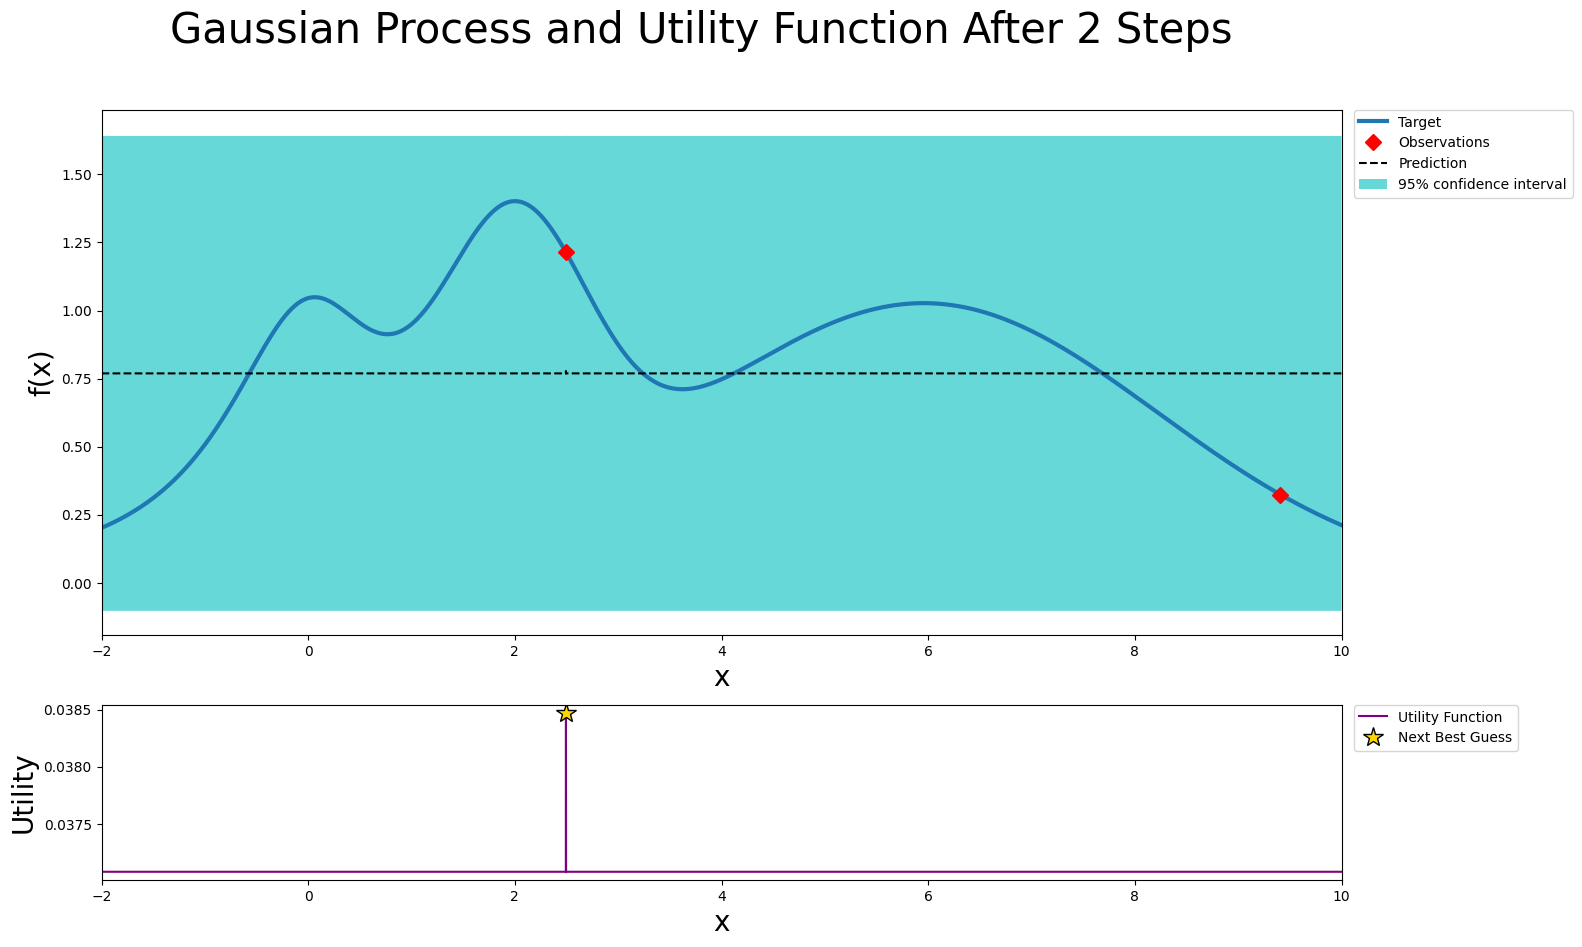

In [92]:
plot_gp(optimizer, x, y)

plt.show()

|   iter    |  target   |     x     |
-------------------------------------
| 6         | 0.9266475 | 4.9022885 |


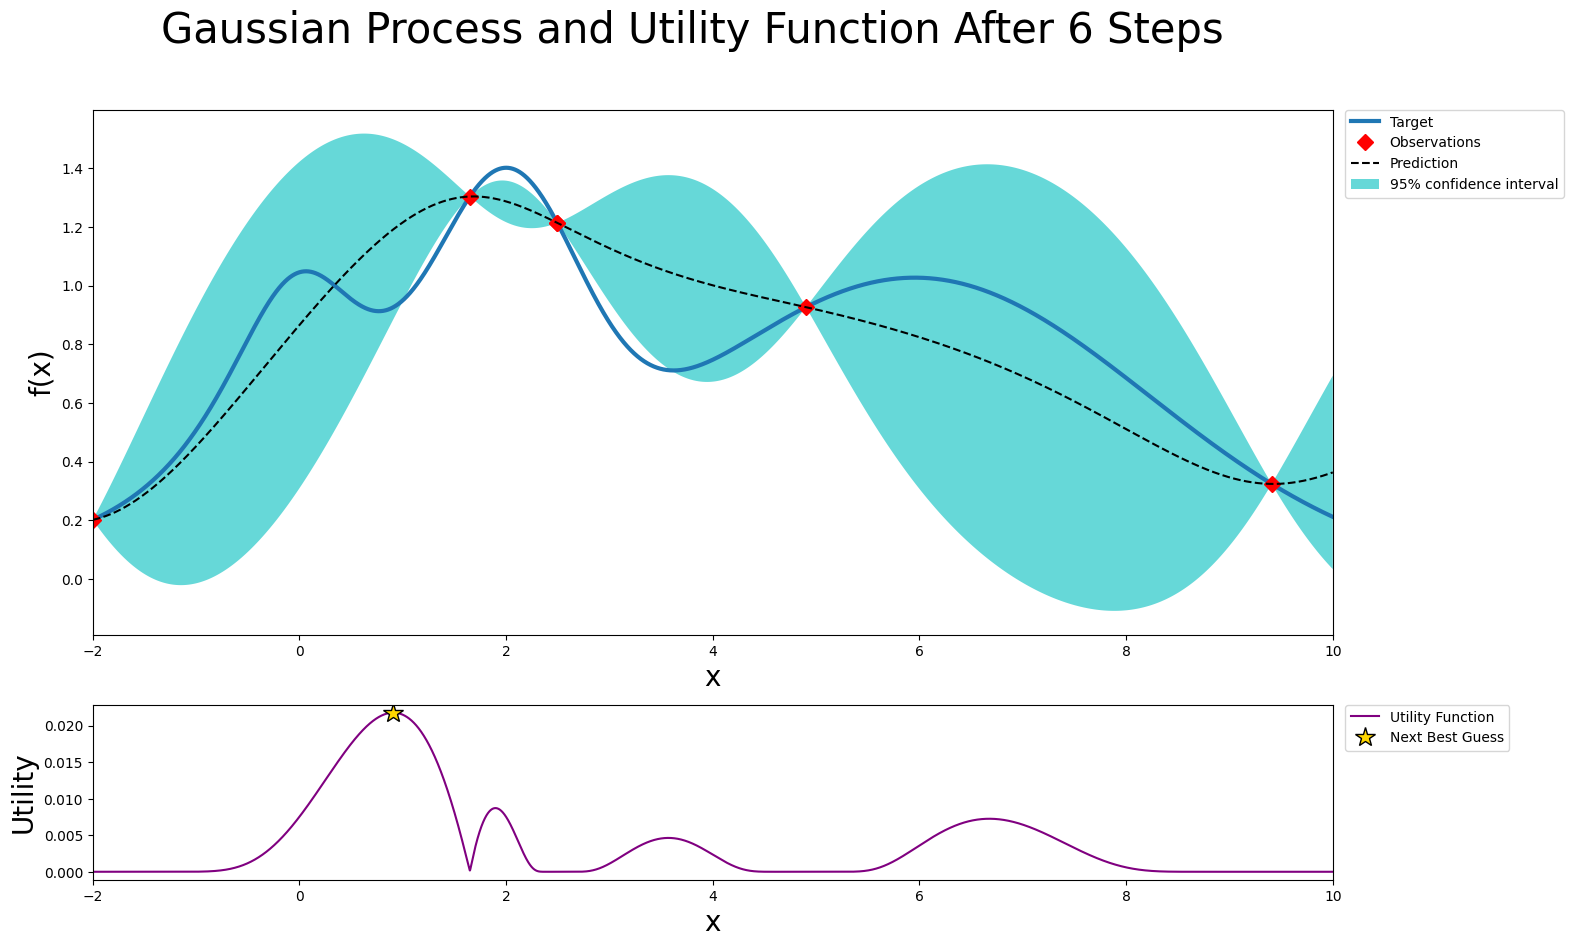

In [96]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)

plt.show()